# 피크 특징 기반 피부층 깊이 예측 — 학습 노트북

**입력**: 힐버트 엔벨로프 피크 특징 벡터 (~20개)  
**출력**: `[dermis_mm, fascia_mm]`  
**평가**: Leave-One-Patient-Out Cross-Validation  
**목표**: 진피 < 0.30mm, 근막 < 0.30mm MAE  
**방법**: Random Forest / XGBoost (scikit-learn)

---
**사용법**
1. `[설정] 하이퍼파라미터` 셀에서 파라미터 조정 후 전체 실행 (`Kernel → Restart & Run All`)
2. 또는 셀 하나씩 실행하며 결과 확인

## 0. 환경 설정

In [1]:
import re, json, pickle, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from IPython.display import display

from scipy.signal import hilbert, find_peaks
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost 사용 가능")
except ImportError:
    HAS_XGB = False
    print("XGBoost 없음 → sklearn GradientBoosting 사용")

# ── 한글 폰트 설정 ────────────────────────────────────────────
_ko_candidates = [f.fname for f in fm.fontManager.ttflist if 'Noto Sans CJK' in f.name]
if _ko_candidates:
    _ko_path = _ko_candidates[0]
    fm.fontManager.addfont(_ko_path)
    _ko_name = fm.FontProperties(fname=_ko_path).get_name()
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [_ko_name, 'DejaVu Sans']
    print(f"한글 폰트 적용: {_ko_name}")
else:
    print("한글 폰트 없음")
plt.rcParams['axes.unicode_minus'] = False

ROOT       = Path(".").resolve()
USDATA     = ROOT / "usdata" / "data"
RESULT_DIR = ROOT / "results"
RESULT_DIR.mkdir(exist_ok=True)

# ── 신호 파라미터 ────────────────────────────────────────────
TRIM_START     = 1850
TRIM_COUNT     = 2050
DISPLAY_OFFSET = 18.50    # μs (저장 데이터 시작 절대 시간)
SAMPLE_PERIOD  = 0.01     # μs/sample

T0_THRESHOLD       = 100.0
DERMIS_EXPECTED_US = 2.33   # T0 기준 예상 μs
DERMIS_STD_US      = 0.33
FASCIA_EXPECTED_US = 5.16
FASCIA_STD_US      = 0.79
SOUND_SPEED        = 1540.0

FILENAME_RE = re.compile(
    r'^(?P<name>.+)_(?P<date>\d{8})_(?P<time>\d{6})_'
    r'\((?P<pos_num>\d+)\)(?P<position>.+?)_(?P<gender>[MF])\.csv$'
)

print(f"USDATA : {USDATA}")
print(f"Results: {RESULT_DIR}")

XGBoost 없음 → sklearn GradientBoosting 사용
한글 폰트 적용: Noto Sans CJK JP
USDATA : /home/dmjang/work/ultrasound_analysis/usdata/data
Results: /home/dmjang/work/ultrasound_analysis/results


## 1. 데이터 로드

In [2]:
def load_adc_stored(path):
    """저장된 ADC 로드 (TRIM_START=1850 이후 2050샘플 또는 이미 trimmed)"""
    adc = []
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:
                v = int(line)
                if 0 <= v <= 255: adc.append(v)
            except ValueError: pass
    adc = np.array(adc, dtype=np.float64)
    if len(adc) >= TRIM_START + TRIM_COUNT:
        adc = adc[TRIM_START:TRIM_START + TRIM_COUNT]
    elif len(adc) > TRIM_START:
        adc = adc[TRIM_START:]
    if len(adc) < TRIM_COUNT:
        adc = np.pad(adc, (0, TRIM_COUNT - len(adc)), constant_values=128)
    return adc[:TRIM_COUNT]


def load_label_with_t0(csv_path):
    """JSON에서 T0 + 라벨 로드"""
    json_path = csv_path.with_name(csv_path.stem + "_positions.json")
    if not json_path.exists(): return None
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)
    t0_us = data.get("start_point_us")
    dermis_mm = fascia_mm = None
    for pos in data.get("positions", []):
        name = pos.get("position_name", "")
        mm   = pos.get("thickness_mm")
        if name in ("피하지방시작", "Dermis") and mm is not None:
            dermis_mm = float(mm)
        elif name == "Fascia" and mm is not None:
            fascia_mm = float(mm)
    if t0_us is None or dermis_mm is None or fascia_mm is None: return None
    return float(t0_us), dermis_mm, fascia_mm


def abs_to_idx(t_us, n):
    """절대 μs → stored 배열 인덱스 (클리핑)"""
    return max(0, min(n - 1, int(round((t_us - DISPLAY_OFFSET) / SAMPLE_PERIOD))))


def window_features(env, i0, i1, expected_rel_us):
    """
    env[i0:i1] 구간에서 9개 특징 추출
    expected_rel_us: 구간 시작(i0)로부터의 예상 피크 위치 (μs)
    """
    seg = env[i0:i1]
    if len(seg) < 3:
        return [0.0] * 9
    rel_us = np.arange(len(seg)) * SAMPLE_PERIOD
    mean_v = float(np.mean(seg))
    std_v  = float(np.std(seg))
    max_v  = float(np.max(seg))
    max_i  = int(np.argmax(seg))
    max_pos = float(rel_us[max_i])

    peaks, props = find_peaks(seg, prominence=max(max_v * 0.1, 1.0), distance=3)
    if len(peaks) > 0:
        best    = int(np.argmin(np.abs(rel_us[peaks] - expected_rel_us)))
        pk_pos  = float(rel_us[peaks[best]])
        pk_amp  = float(seg[peaks[best]])
        pk_prom = float(props["prominences"][best])
    else:
        pk_pos, pk_amp, pk_prom = max_pos, max_v, 0.0

    energy = float(np.sum(seg ** 2) / max(len(seg), 1))
    return [mean_v, std_v, max_v, max_pos, pk_pos, pk_amp, pk_prom, energy, float(len(peaks))]


FEATURE_NAMES = (
    ["t0_us", "t0_amp"] +
    [f"d_{n}" for n in ["mean","std","max","maxpos","pkpos","pkamp","pkprom","energy","npeaks"]] +
    [f"f_{n}" for n in ["mean","std","max","maxpos","pkpos","pkamp","pkprom","energy","npeaks"]]
)
N_FEATURES = len(FEATURE_NAMES)


def extract_features(adc_stored, t0_us):
    """힐버트 엔벨로프 기반 피크 특징 벡터 추출"""
    n   = len(adc_stored)
    env = np.abs(hilbert(adc_stored - 128.0))

    t0_idx = abs_to_idx(t0_us, n)
    t0_amp = float(env[t0_idx])

    # 진피 창
    di0 = abs_to_idx(t0_us + DERMIS_EXPECTED_US - DERMIS_STD_US, n)
    di1 = abs_to_idx(t0_us + DERMIS_EXPECTED_US + DERMIS_STD_US, n)
    d_feats = window_features(env, di0, di1, DERMIS_STD_US)

    # 근막 창
    fi0 = abs_to_idx(t0_us + FASCIA_EXPECTED_US - FASCIA_STD_US, n)
    fi1 = abs_to_idx(t0_us + FASCIA_EXPECTED_US + FASCIA_STD_US, n)
    f_feats = window_features(env, fi0, fi1, FASCIA_STD_US)

    return np.array([t0_us, t0_amp] + d_feats + f_feats, dtype=np.float32)


def build_dataset():
    rows, failed = [], 0
    for csv_path in sorted(USDATA.rglob("*.csv")):
        if "_positions" in csv_path.name: continue
        m = FILENAME_RE.match(csv_path.name)
        if not m: continue
        label = load_label_with_t0(csv_path)
        if label is None: continue
        t0_us, dermis_mm, fascia_mm = label
        try:
            adc = load_adc_stored(csv_path)
        except Exception:
            failed += 1; continue
        feats = extract_features(adc, t0_us)
        rows.append({
            "patient": m.group("name"),
            "pos_num": int(m.group("pos_num")),
            "features": feats,
            "dermis":   dermis_mm,
            "fascia":   fascia_mm,
        })
    if failed:
        print(f"  [경고] 로드 실패: {failed}개")
    return rows


ALL_ROWS = build_dataset()
patients = sorted({r["patient"] for r in ALL_ROWS})

X_ALL = np.stack([r["features"] for r in ALL_ROWS])
Y_ALL = np.array([[r["dermis"], r["fascia"]] for r in ALL_ROWS])

print(f"총 샘플: {len(ALL_ROWS)}개  /  환자: {len(patients)}명")
print(f"특징 수: {N_FEATURES}")
print(f"특징명: {FEATURE_NAMES}")
print(f"\n진피  평균: {Y_ALL[:,0].mean():.3f} ± {Y_ALL[:,0].std():.3f} mm  [{Y_ALL[:,0].min():.2f}~{Y_ALL[:,0].max():.2f}]")
print(f"근막  평균: {Y_ALL[:,1].mean():.3f} ± {Y_ALL[:,1].std():.3f} mm  [{Y_ALL[:,1].min():.2f}~{Y_ALL[:,1].max():.2f}]")

총 샘플: 806개  /  환자: 20명
특징 수: 20
특징명: ['t0_us', 't0_amp', 'd_mean', 'd_std', 'd_max', 'd_maxpos', 'd_pkpos', 'd_pkamp', 'd_pkprom', 'd_energy', 'd_npeaks', 'f_mean', 'f_std', 'f_max', 'f_maxpos', 'f_pkpos', 'f_pkamp', 'f_pkprom', 'f_energy', 'f_npeaks']

진피  평균: 1.786 ± 0.118 mm  [1.54~2.05]
근막  평균: 3.969 ± 0.064 mm  [3.76~4.13]


## 2. 모델 정의 (Random Forest / XGBoost)

In [3]:
def make_rf(n_estimators=200, max_depth=None, min_samples_leaf=3, random_state=42):
    return MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            n_jobs=-1,
            random_state=random_state,
        )
    )


def make_xgb(n_estimators=300, max_depth=4, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8, random_state=42):
    if HAS_XGB:
        base = xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=random_state,
            verbosity=0,
        )
    else:
        base = GradientBoostingRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            random_state=random_state,
        )
    return MultiOutputRegressor(base)


MODEL_DEFS = {
    "RF":  make_rf,
    "XGB": make_xgb,
}

print("모델 정의 완료:")
for name, fn in MODEL_DEFS.items():
    print(f"  {name}: {fn()}")

모델 정의 완료:
  RF: MultiOutputRegressor(estimator=RandomForestRegressor(min_samples_leaf=3,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42))
  XGB: MultiOutputRegressor(estimator=GradientBoostingRegressor(learning_rate=0.05,
                                                         max_depth=4,
                                                         n_estimators=300,
                                                         random_state=42,
                                                         subsample=0.8))


## 3. [설정] 하이퍼파라미터 ← 여기서 변경

이 셀만 수정 후 아래 셀들을 순서대로 실행합니다.

In [4]:
# ┌──────────────────────────────────────────────────┐
# │  하이퍼파라미터 설정                               │
# └──────────────────────────────────────────────────┘

HP_RF = dict(
    n_estimators     = 200,
    max_depth        = None,   # None = 무제한
    min_samples_leaf = 3,
)

HP_XGB = dict(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
)

# LOO-CV에 포함할 모델 (제거하면 해당 모델 제외)
CV_MODELS = {
    "RF":  lambda: make_rf(**HP_RF),
    "XGB": lambda: make_xgb(**HP_XGB),
}

print("RF  하이퍼파라미터:", HP_RF)
print("XGB 하이퍼파라미터:", HP_XGB)
print(f"\nLOO-CV 대상 모델: {list(CV_MODELS.keys())}")

RF  하이퍼파라미터: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3}
XGB 하이퍼파라미터: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}

LOO-CV 대상 모델: ['RF', 'XGB']


## 4. 학습 / 평가 함수

In [5]:
def train_and_eval(model, X_tr, Y_tr, X_val, Y_val):
    """sklearn 모델 학습 및 MAE 평가"""
    model.fit(X_tr, Y_tr)
    preds  = model.predict(X_val)
    mae_d  = float(np.mean(np.abs(preds[:, 0] - Y_val[:, 0])))
    mae_f  = float(np.mean(np.abs(preds[:, 1] - Y_val[:, 1])))
    return preds, mae_d, mae_f


print("학습 함수 정의 완료")

학습 함수 정의 완료


## 5. 단일 학습 (마지막 환자 검증)

마지막 환자를 검증셋으로 고정하여 빠르게 모델 동작 확인

In [6]:
val_pat  = patients[-1]
mask_tr  = np.array([r["patient"] != val_pat for r in ALL_ROWS])
mask_val = ~mask_tr

X_tr,  Y_tr  = X_ALL[mask_tr],  Y_ALL[mask_tr]
X_val, Y_val = X_ALL[mask_val], Y_ALL[mask_val]

print(f"Train: {mask_tr.sum()}개  /  Val: {mask_val.sum()}개 (환자: {val_pat})\n")

single_preds = {}
for name, fn in CV_MODELS.items():
    m = fn()
    preds_v, mae_d, mae_f = train_and_eval(m, X_tr, Y_tr, X_val, Y_val)
    single_preds[name] = (preds_v, mae_d, mae_f)
    sd = "✓ OK" if mae_d < 0.3 else "✗ NG"
    sf = "✓ OK" if mae_f < 0.3 else "✗ NG"
    print(f"[{name}]  진피 {mae_d:.4f}mm {sd}  근막 {mae_f:.4f}mm {sf}")

Train: 763개  /  Val: 43개 (환자: 황인홍)

[RF]  진피 0.0901mm ✓ OK  근막 0.0494mm ✓ OK
[XGB]  진피 0.0929mm ✓ OK  근막 0.0523mm ✓ OK


## 6. LOO-CV (Leave-One-Patient-Out)

In [7]:
def run_loo_cv(all_rows, X, Y, model_fns):
    patients = sorted({r["patient"] for r in all_rows})
    pat_ids  = np.array([r["patient"] for r in all_rows])
    results  = {name: [] for name in model_fns}

    print(f"LOO-CV 시작: {len(patients)}명  /  모델: {list(model_fns.keys())}")
    print("-" * 72)

    for i, pat in enumerate(patients):
        mask_tr  = pat_ids != pat
        mask_val = pat_ids == pat
        X_tr, Y_tr  = X[mask_tr],  Y[mask_tr]
        X_val,Y_val = X[mask_val], Y[mask_val]

        row_str = f"  [{i+1:2d}/{len(patients)}] {pat:<12s}"
        for name, fn in model_fns.items():
            preds, mae_d, mae_f = train_and_eval(fn(), X_tr, Y_tr, X_val, Y_val)
            results[name].append({
                "patient":    pat,
                "n":          int(mask_val.sum()),
                "mae_dermis": mae_d,
                "mae_fascia": mae_f,
                "preds":      preds,
                "trues":      Y_val,
            })
            row_str += f"  [{name}] D={mae_d:.3f} F={mae_f:.3f}"
        print(row_str + f"  (n={mask_val.sum()})")

    print("-" * 72)
    dfs = {}
    for name, recs in results.items():
        df = pd.DataFrame(recs)
        dfs[name] = df
        print(f"  [{name}]  진피 {df['mae_dermis'].mean():.3f}±{df['mae_dermis'].std():.3f}mm"
              f"  근막 {df['mae_fascia'].mean():.3f}±{df['mae_fascia'].std():.3f}mm")
    return dfs


CV_DFS = run_loo_cv(ALL_ROWS, X_ALL, Y_ALL, CV_MODELS)

LOO-CV 시작: 20명  /  모델: ['RF', 'XGB']
------------------------------------------------------------------------
  [ 1/20] 권영남           [RF] D=0.088 F=0.049  [XGB] D=0.087 F=0.050  (n=50)
  [ 2/20] 김선일           [RF] D=0.084 F=0.045  [XGB] D=0.086 F=0.045  (n=38)
  [ 3/20] 김수현           [RF] D=0.096 F=0.046  [XGB] D=0.105 F=0.049  (n=30)
  [ 4/20] 김희락           [RF] D=0.101 F=0.056  [XGB] D=0.110 F=0.065  (n=47)
  [ 5/20] 박성수           [RF] D=0.110 F=0.067  [XGB] D=0.113 F=0.068  (n=38)
  [ 6/20] 박인석           [RF] D=0.121 F=0.071  [XGB] D=0.128 F=0.073  (n=32)
  [ 7/20] 박인식           [RF] D=0.088 F=0.050  [XGB] D=0.089 F=0.049  (n=47)
  [ 8/20] 서영수           [RF] D=0.108 F=0.051  [XGB] D=0.115 F=0.057  (n=47)
  [ 9/20] 송용범           [RF] D=0.111 F=0.056  [XGB] D=0.110 F=0.056  (n=40)
  [10/20] 송인광           [RF] D=0.081 F=0.048  [XGB] D=0.072 F=0.048  (n=29)
  [11/20] 양창식           [RF] D=0.090 F=0.048  [XGB] D=0.098 F=0.052  (n=46)
  [12/20] 오광            [RF] D=0.094 F=0.049  [XGB] D=

## 7. 결과 시각화

저장: /home/dmjang/work/ultrasound_analysis/results/peak_model_cv.png


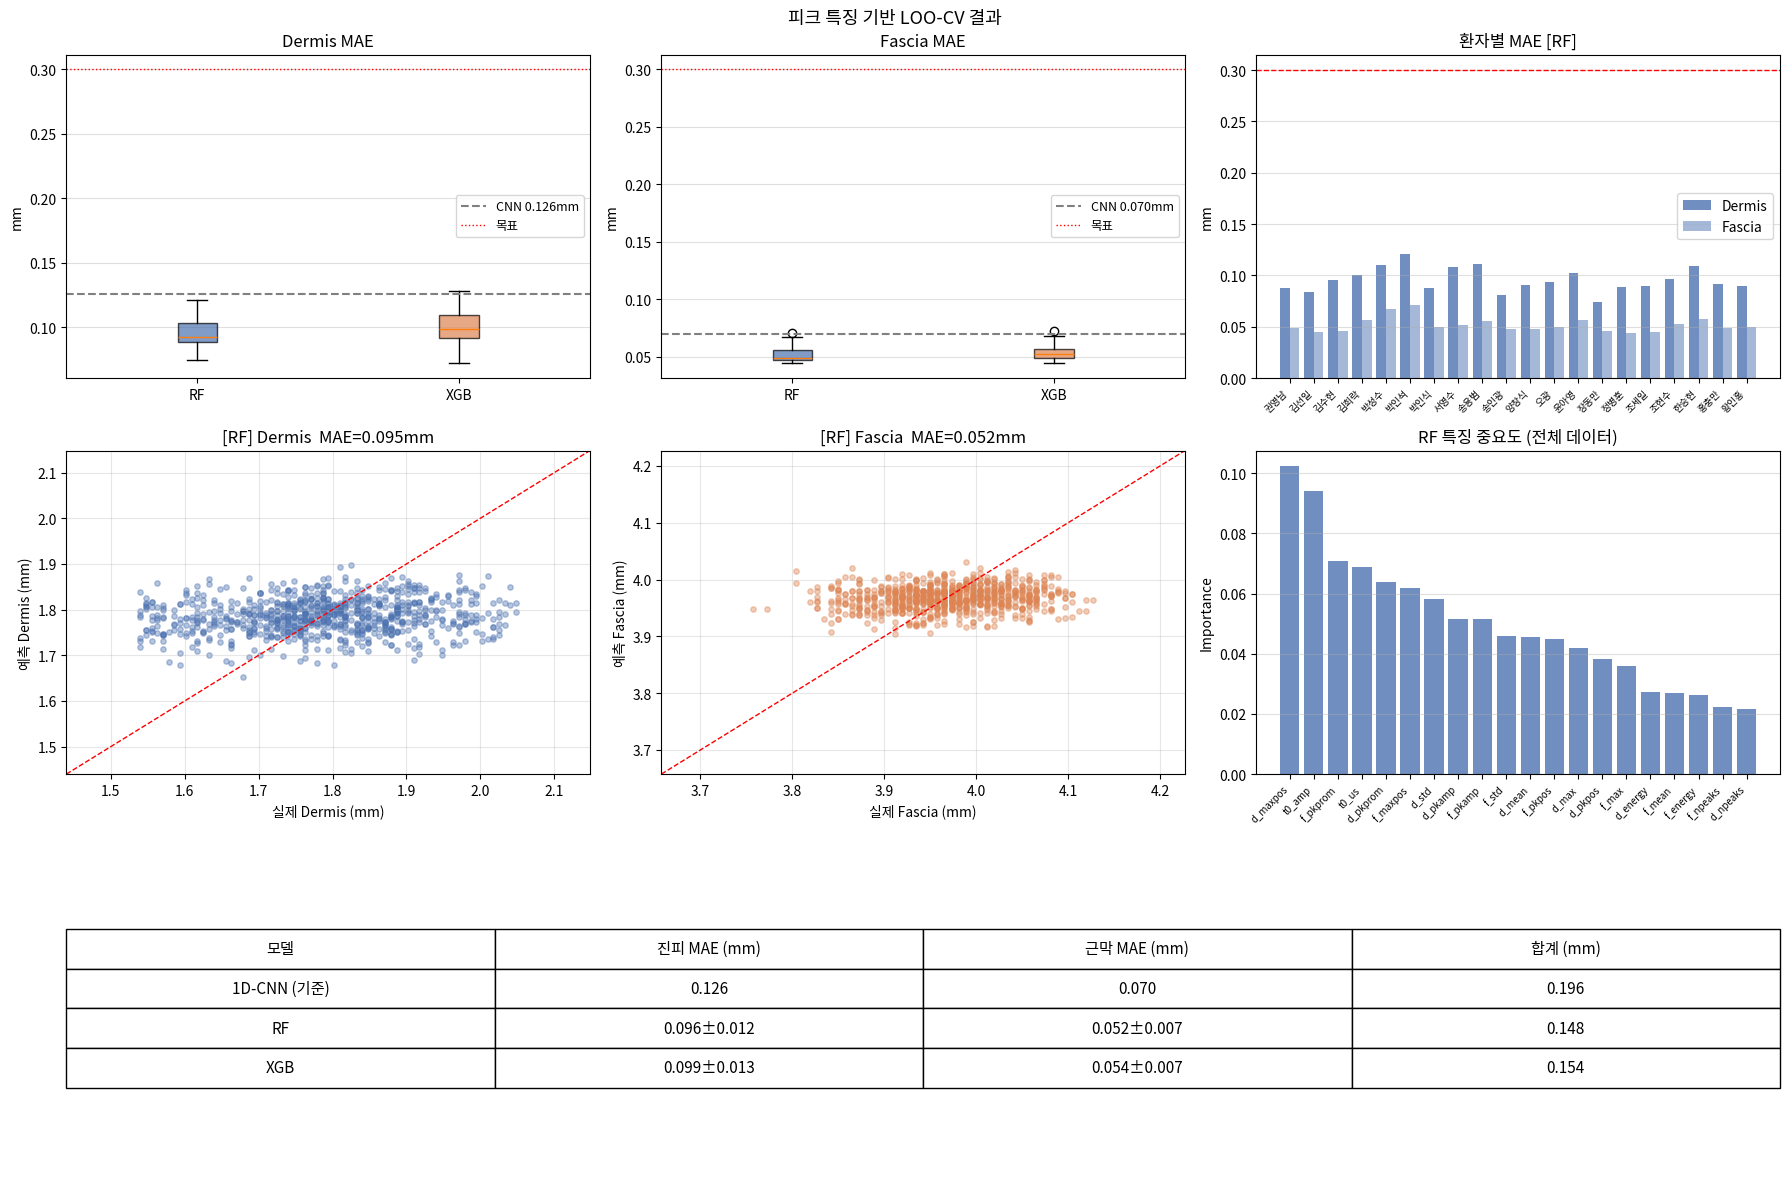

In [8]:
CNN_MAE = {"dermis": 0.126, "fascia": 0.070}   # 1D-CNN LOO-CV 기준선
colors   = {"RF": "#4c72b0", "XGB": "#dd8452"}
model_names = list(CV_DFS.keys())

best_name = min(model_names,
    key=lambda n: CV_DFS[n]["mae_dermis"].mean() + CV_DFS[n]["mae_fascia"].mean())

fig = plt.figure(figsize=(18, 12))
fig.suptitle("피크 특징 기반 LOO-CV 결과", fontsize=13)
gs = gridspec.GridSpec(3, 3, figure=fig)

# ① Dermis MAE 박스플롯
ax = fig.add_subplot(gs[0, 0])
bp = ax.boxplot([CV_DFS[n]["mae_dermis"].values for n in model_names],
                tick_labels=model_names, patch_artist=True)
for patch, n in zip(bp["boxes"], model_names):
    patch.set_facecolor(colors.get(n, "#888")); patch.set_alpha(0.7)
ax.axhline(CNN_MAE["dermis"], color="gray", linestyle="--", lw=1.5, label=f"CNN {CNN_MAE['dermis']:.3f}mm")
ax.axhline(0.3, color="red", linestyle=":", lw=1, label="목표")
ax.set_title("Dermis MAE"); ax.set_ylabel("mm"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# ② Fascia MAE 박스플롯
ax = fig.add_subplot(gs[0, 1])
bp = ax.boxplot([CV_DFS[n]["mae_fascia"].values for n in model_names],
                tick_labels=model_names, patch_artist=True)
for patch, n in zip(bp["boxes"], model_names):
    patch.set_facecolor(colors.get(n, "#888")); patch.set_alpha(0.7)
ax.axhline(CNN_MAE["fascia"], color="gray", linestyle="--", lw=1.5, label=f"CNN {CNN_MAE['fascia']:.3f}mm")
ax.axhline(0.3, color="red", linestyle=":", lw=1, label="목표")
ax.set_title("Fascia MAE"); ax.set_ylabel("mm"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# ③ 환자별 MAE 막대 (최선 모델)
ax = fig.add_subplot(gs[0, 2])
df = CV_DFS[best_name]
x  = np.arange(len(df))
ax.bar(x - 0.2, df["mae_dermis"], 0.4, label="Dermis", color=colors.get(best_name, "#888"), alpha=0.8)
ax.bar(x + 0.2, df["mae_fascia"], 0.4, label="Fascia",  color=colors.get(best_name, "#888"), alpha=0.5)
ax.axhline(0.3, color="red", linestyle="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(df["patient"], rotation=45, ha="right", fontsize=7)
ax.set_title(f"환자별 MAE [{best_name}]"); ax.set_ylabel("mm"); ax.legend(); ax.grid(axis="y", alpha=0.4)

# ④⑤ 스캐터 플롯 (최선 모델)
all_preds = np.concatenate(CV_DFS[best_name]["preds"].tolist())
all_trues = np.concatenate(CV_DFS[best_name]["trues"].tolist())
for col, (ti, label, color) in enumerate([(0, "Dermis", "#4c72b0"), (1, "Fascia", "#dd8452")]):
    ax = fig.add_subplot(gs[1, col])
    ax.scatter(all_trues[:, ti], all_preds[:, ti], alpha=0.4, s=15, color=color)
    lim = [min(all_trues[:, ti].min(), all_preds[:, ti].min()) - 0.1,
           max(all_trues[:, ti].max(), all_preds[:, ti].max()) + 0.1]
    ax.plot(lim, lim, "r--", lw=1)
    mae = float(np.mean(np.abs(all_preds[:, ti] - all_trues[:, ti])))
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"실제 {label} (mm)"); ax.set_ylabel(f"예측 {label} (mm)")
    ax.set_title(f"[{best_name}] {label}  MAE={mae:.3f}mm"); ax.grid(alpha=0.3)

# ⑥ RF 특징 중요도 (전체 데이터 학습)
ax = fig.add_subplot(gs[1, 2])
rf_full = make_rf(**HP_RF)
rf_full.fit(X_ALL, Y_ALL)
imps = np.mean([e.feature_importances_ for e in rf_full.estimators_], axis=0)
idx  = np.argsort(imps)[::-1]
ax.bar(range(N_FEATURES), imps[idx], color="#4c72b0", alpha=0.8)
ax.set_xticks(range(N_FEATURES))
ax.set_xticklabels([FEATURE_NAMES[i] for i in idx], rotation=45, ha="right", fontsize=7)
ax.set_title("RF 특징 중요도 (전체 데이터)"); ax.set_ylabel("Importance"); ax.grid(axis="y", alpha=0.4)

# ⑦ 모델 비교 요약 표
ax = fig.add_subplot(gs[2, :])
ax.axis("off")
header = ["모델", "진피 MAE (mm)", "근막 MAE (mm)", "합계 (mm)"]
rows_t = [["1D-CNN (기준)",
           f"{CNN_MAE['dermis']:.3f}",
           f"{CNN_MAE['fascia']:.3f}",
           f"{CNN_MAE['dermis']+CNN_MAE['fascia']:.3f}"]]
for n in model_names:
    d  = CV_DFS[n]["mae_dermis"].mean()
    ds = CV_DFS[n]["mae_dermis"].std()
    f  = CV_DFS[n]["mae_fascia"].mean()
    fs = CV_DFS[n]["mae_fascia"].std()
    rows_t.append([n, f"{d:.3f}±{ds:.3f}", f"{f:.3f}±{fs:.3f}", f"{d+f:.3f}"])
tbl = ax.table(cellText=rows_t, colLabels=header, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2)

fig.tight_layout()
out = RESULT_DIR / "peak_model_cv.png"
fig.savefig(out, dpi=150)
print(f"저장: {out}")
plt.show()

## 8. 최종 모델 저장

In [9]:
print("최종 모델 학습 중 (전체 데이터)...")

best_name = min(CV_MODELS.keys(),
    key=lambda n: CV_DFS[n]["mae_dermis"].mean() + CV_DFS[n]["mae_fascia"].mean())

final_model = CV_MODELS[best_name]()
final_model.fit(X_ALL, Y_ALL)
print(f"최종 모델: {best_name}")

save_path = RESULT_DIR / "best_peak_model.pkl"
with open(save_path, "wb") as fh:
    pickle.dump({
        "model":              final_model,
        "model_name":         best_name,
        "feature_names":      FEATURE_NAMES,
        "n_features":         N_FEATURES,
        "display_offset_us":  DISPLAY_OFFSET,
        "sample_period_us":   SAMPLE_PERIOD,
        "dermis_expected_us": DERMIS_EXPECTED_US,
        "dermis_std_us":      DERMIS_STD_US,
        "fascia_expected_us": FASCIA_EXPECTED_US,
        "fascia_std_us":      FASCIA_STD_US,
        "cv_mae_dermis":      {n: float(CV_DFS[n]["mae_dermis"].mean()) for n in CV_MODELS},
        "cv_mae_fascia":      {n: float(CV_DFS[n]["mae_fascia"].mean()) for n in CV_MODELS},
    }, fh)
print(f"모델 저장: {save_path}")

print(f"\n{'모델':<22s}  {'진피 MAE':>12s}  {'근막 MAE':>12s}")
print("-" * 52)
print(f"{'1D-CNN (기준)':<22s}  {CNN_MAE['dermis']:>8.3f}mm  {CNN_MAE['fascia']:>8.3f}mm")
for n in model_names:
    d = CV_DFS[n]["mae_dermis"].mean()
    f = CV_DFS[n]["mae_fascia"].mean()
    mark = " ← 최선" if n == best_name else ""
    print(f"{n:<22s}  {d:>8.3f}mm  {f:>8.3f}mm{mark}")

최종 모델 학습 중 (전체 데이터)...
최종 모델: RF
모델 저장: /home/dmjang/work/ultrasound_analysis/results/best_peak_model.pkl

모델                            진피 MAE        근막 MAE
----------------------------------------------------
1D-CNN (기준)                0.126mm     0.070mm
RF                         0.096mm     0.052mm ← 최선
XGB                        0.099mm     0.054mm
